# Backbone Evaluation (DETERMINISTIC) — Glomeruli Project (FP03)

Corrected version of `evaluation.ipynb`. It reproduces the **deterministic** backbone
evaluation described in `CONTESTO_PROGETTO.md`, i.e. an evaluation that does **not** depend
on any random seed (no UMAP here — UMAP belongs to `clustering.ipynb`).

### What changed vs the previous notebook
1. **Separability is now swept over 9 configurations** — 3 normalizations
   (`standard` / `l2` / `none`) × 3 PCA sizes (`5` / `10` / `20`) — and the ranking is the
   **mean of the best Ward silhouette across the 9 configs** (this is what the context
   reports). A separate **no-PCA control** (3 normalizations, full space) shows that the
   structure collapses without PCA.
2. **Augmentation-invariance section added** (rotations / flips). This is the only section
   that re-runs the backbones (TensorFlow + weights), so it is heavy and optional.

### Reproducibility notes
- All metrics use fixed seeds: PCA `svd_solver="full"`, Ward (no seed), scikit-learn HDBSCAN
  (deterministic), Hopkins `random_state=42`, gradation pair-sampling `random_state=42`.
- The evaluation is bit-reproducible **as long as you start from the same `.npy` embeddings**.
  Re-extracting embeddings goes through TensorFlow/keras and is not guaranteed identical.

## Sections
1. Setup & loading
2. Sanity checks
3. Cosine similarity & nearest neighbors + Hopkins
4. **Separability — 9-config sweep + no-PCA control**
5. Continuous gradation *(optional)*
6. 2D visualization *(optional)*
7. **Augmentation invariance** *(optional, heavy)*
8. Summary table

## 1. Setup & loading

`NORMALIZATION` / `PCA_N_COMPONENTS` are the **primary** preprocessing used for the light
sections (NN, Hopkins, gradation, viz), matching the clustering pipeline (L2 + PCA 10).
The separability sweep in Section 4 uses its own grid.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- make src/ importable (run from repo root or notebooks/) ---
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").is_dir():
    pass
elif (PROJECT_ROOT.parent / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- paths ---
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"
CROPS_DIR      = PROJECT_ROOT / "data" / "glomeruli" / "crops"
MASKS_DIR      = PROJECT_ROOT / "data" / "glomeruli" / "masks"

RESULTS_DIR = PROJECT_ROOT / "results" / "backbone_evaluation"
FIG_DIR     = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- primary preprocessing (light sections), consistent with the clustering pipeline ---
NORMALIZATION    = "l2"     # "standard" | "l2" | "none"
PCA_N_COMPONENTS = 10       # 0 = no PCA
RANDOM_STATE     = 42
K_NEIGHBORS      = 15

# --- deterministic separability sweep grid (context section 4) ---
SWEEP_NORMALIZATIONS = ["standard", "l2", "none"]   # 3 normalizations
SWEEP_PCA_COMPONENTS = [5, 10, 20]                  # 3 PCA sizes -> 9 configs
SWEEP_PCA_CONTROL    = 0                            # no-PCA control (full space)

print("Project root:", PROJECT_ROOT)
print("Embeddings dir:", EMBEDDINGS_DIR)
print("Results ->", RESULTS_DIR)

Project root: c:\Users\alexa\Desktop\Glomeruli-FP03-2026
Embeddings dir: c:\Users\alexa\Desktop\Glomeruli-FP03-2026\data\glomeruli\embeddings
Results -> c:\Users\alexa\Desktop\Glomeruli-FP03-2026\results\backbone_evaluation


In [2]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA


def load_all_embeddings(embeddings_dir: Path, pattern: str = "*.npy") -> dict:
    """Load every .npy embedding file into a dict {backbone_name: array}."""
    data = {}
    for path in sorted(embeddings_dir.glob(pattern)):
        X = np.load(path)
        if X.ndim != 2:
            print(f"  [SKIP] {path.name}: shape {X.shape}")
            continue
        name = path.stem.replace("_crops_embeddings", "").replace("_embeddings", "")
        data[name] = X.astype(np.float64)
    return data


def preprocess(X: np.ndarray, normalization: str = NORMALIZATION,
               pca_n: int = PCA_N_COMPONENTS, random_state: int = RANDOM_STATE) -> np.ndarray:
    """Normalization + optional PCA. Fully deterministic (svd_solver='full')."""
    if normalization == "standard":
        X = StandardScaler().fit_transform(X)
    elif normalization == "l2":
        X = normalize(X, norm="l2", axis=1)
    X = X.astype(np.float64)
    if pca_n and pca_n > 0 and X.shape[1] > pca_n:
        n = min(pca_n, X.shape[0] - 1)
        X = PCA(n_components=n, svd_solver="full", random_state=random_state).fit_transform(X)
    return X


embeddings = load_all_embeddings(EMBEDDINGS_DIR)
print(f"Loaded {len(embeddings)} backbones:")
for name, X in embeddings.items():
    print(f"  {name:22s} shape={X.shape}")

Loaded 11 backbones:
  densenet201            shape=(677, 1920)
  densenet               shape=(677, 1664)
  dinov2_base_cls        shape=(677, 768)
  dinov2_base_patch      shape=(677, 768)
  dinov3_base_cls        shape=(677, 768)
  dinov3_base_patch      shape=(677, 768)
  kimianet_1000          shape=(677, 1024)
  kimianet_224           shape=(677, 1024)
  mobilenet              shape=(677, 1024)
  nasnet                 shape=(677, 4032)
  xception               shape=(677, 2048)


## 2. Sanity checks

Discard degenerate embeddings before comparing: exact duplicates and anomalous
(near-zero / outlier) norms.

In [3]:
from src.metrics.embedding_evaluation import find_exact_duplicate, evaluate_embedding_norms

sanity_rows = []
for name, X in embeddings.items():
    dupes = find_exact_duplicate(X)
    n_dupes = 0 if dupes is None else len(dupes)
    norm_info = evaluate_embedding_norms(X)
    sanity_rows.append({
        "backbone": name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "n_exact_duplicates": n_dupes,
        "n_near_zero_norm": len(norm_info["near_zero_indices"]),
        "n_norm_outliers": len(norm_info["low_outlier_indices"]) + len(norm_info["high_outlier_indices"]),
    })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df.to_csv(RESULTS_DIR / "sanity_checks.csv", index=False)
sanity_df

,backbone,n_samples,n_features,n_exact_duplicates,n_near_zero_norm,n_norm_outliers
0,densenet201,677,1920,0,0,0
1,densenet,677,1664,0,0,0
2,dinov2_base_cls,677,768,0,0,0
3,dinov2_base_patch,677,768,0,0,0
4,dinov3_base_cls,677,768,0,0,1
5,dinov3_base_patch,677,768,0,0,1
6,kimianet_1000,677,1024,0,0,0
7,kimianet_224,677,1024,0,0,1
8,mobilenet,677,1024,0,0,0
9,nasnet,677,4032,0,0,0


## 3. Cosine similarity & nearest neighbors + Hopkins

Geometry of each embedding space, independent of clustering: cosine-distance spread,
Mutual Nearest Neighbor ratio, hubness, and the Hopkins clusterability statistic.

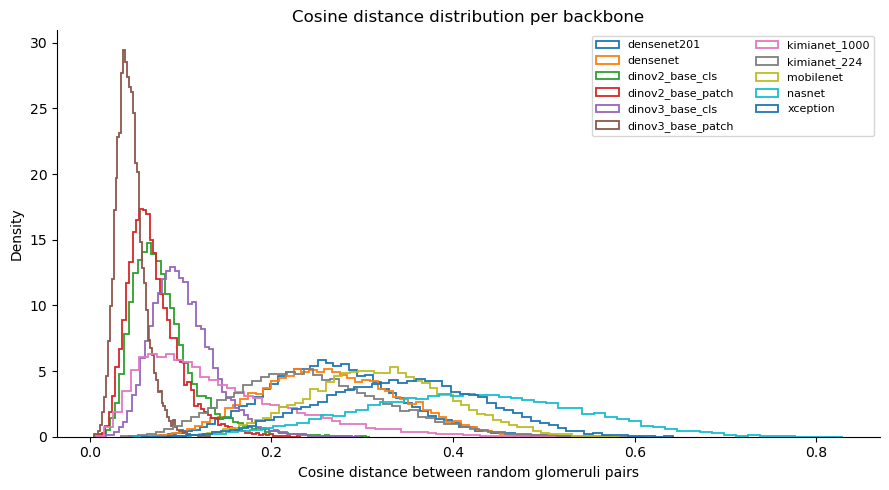

In [4]:
from sklearn.metrics import pairwise_distances

# --- cosine distance distribution per backbone (on L2-normalized space) ---
fig, ax = plt.subplots(figsize=(9, 5))
for name, X in embeddings.items():
    Xp = normalize(X, norm="l2", axis=1)
    rng = np.random.default_rng(RANDOM_STATE)
    n = Xp.shape[0]
    idx_a = rng.integers(0, n, size=20000)
    idx_b = rng.integers(0, n, size=20000)
    valid = idx_a != idx_b
    d = 1.0 - np.sum(Xp[idx_a[valid]] * Xp[idx_b[valid]], axis=1)
    ax.hist(d, bins=60, histtype="step", label=name, density=True, linewidth=1.3)

ax.set_xlabel("Cosine distance between random glomeruli pairs")
ax.set_ylabel("Density")
ax.set_title("Cosine distance distribution per backbone")
ax.legend(fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "cosine_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from src.metrics.nearest_neighbor import evaluate_embedding_backbone

nn_rows = []
for name, X in embeddings.items():
    Xp = preprocess(X)
    try:
        nn_df = evaluate_embedding_backbone(Xp)
        row = {"backbone": name}
        for col in nn_df.columns:
            row[col] = float(nn_df[col].iloc[0])
        nn_rows.append(row)
    except Exception as e:
        print(f"  [WARN] {name}: {e}")

nn_results = pd.DataFrame(nn_rows)
nn_results.to_csv(RESULTS_DIR / "nearest_neighbor_metrics.csv", index=False)
nn_results

,backbone,MNN@5,MNN@10,MNN@20,hubness skew,max hubness
0,densenet201,0.633383,0.682422,0.719645,0.552641,28.0
1,densenet,0.632792,0.676219,0.701182,0.589198,26.0
2,dinov2_base_cls,0.662925,0.687445,0.723634,0.447732,28.0
3,dinov2_base_patch,0.653471,0.693353,0.725849,0.423640,26.0
4,dinov3_base_cls,0.652290,0.668538,0.700591,0.739742,30.0
5,dinov3_base_patch,0.646381,0.683309,0.732201,0.472106,27.0
6,kimianet_1000,0.620384,0.641359,0.651846,0.446370,27.0
7,kimianet_224,0.645199,0.688626,0.742393,0.452321,25.0
8,mobilenet,0.618612,0.653767,0.682866,0.797098,33.0
9,nasnet,0.602068,0.648449,0.696898,0.382675,25.0


In [6]:
from src.metrics.hopkins import compute_hopkins_dataframe

hopkins_rows = []
for name, X in embeddings.items():
    Xp = preprocess(X)
    hdf = compute_hopkins_dataframe(Xp, n_runs=50, random_state=RANDOM_STATE)
    hopkins_rows.append({
        "backbone": name,
        "hopkins_mean": float(hdf["hopkins_mean"].iloc[0]),
        "hopkins_std": float(hdf["hopkins_std"].iloc[0]),
    })

hopkins_df = pd.DataFrame(hopkins_rows).sort_values("hopkins_mean", ascending=False)
hopkins_df.to_csv(RESULTS_DIR / "hopkins.csv", index=False)
hopkins_df

,backbone,hopkins_mean,hopkins_std
3,dinov2_base_patch,0.736859,0.009946
4,dinov3_base_cls,0.726521,0.007988
2,dinov2_base_cls,0.723480,0.009458
5,dinov3_base_patch,0.714709,0.007987
8,mobilenet,0.713730,0.009084
6,kimianet_1000,0.707866,0.009569
0,densenet201,0.703324,0.007356
9,nasnet,0.691082,0.005915
1,densenet,0.679909,0.008121
10,xception,0.671541,0.006865


## 4. Separability — 9-config sweep + no-PCA control

This is the core deterministic evaluation. For **every backbone** and **every configuration**
(3 normalizations × 3 PCA sizes) we compute, on the preprocessed space:

- **Ward** best silhouette over k (deterministic hierarchical clustering);
- **HDBSCAN** best DBCV and minimum noise fraction (density-based, scikit-learn, deterministic).

The ranking reported in the context is the **mean of the best Ward silhouette across the 9
configs** — a backbone that is genuinely better stays on top regardless of preprocessing.

In [7]:
from src.metrics.deterministic_separability import (
    ward_clustering_curve, summarize_ward_curve,
    hdbscan_clustering_metrics, summarize_hdbscan_metrics,
)


def separability_for_space(Xp: np.ndarray) -> dict:
    """Deterministic Ward + HDBSCAN summary on an already-preprocessed space."""
    ward_curve = ward_clustering_curve(
        Xp, k_values=tuple(range(2, 16)),
        max_samples_for_metrics=None, random_state=RANDOM_STATE,
    )
    ward_sum = summarize_ward_curve(ward_curve)
    try:
        hdb_df = hdbscan_clustering_metrics(
            Xp, min_cluster_sizes=(10, 20, 40), random_state=RANDOM_STATE,
        )
        hdb_sum = summarize_hdbscan_metrics(hdb_df)
    except Exception as e:
        print(f"   [WARN] HDBSCAN: {e}")
        hdb_sum = {}
    return {
        "ward_best_silhouette": ward_sum.get("best_silhouette"),
        "ward_best_k": ward_sum.get("best_k_silhouette"),
        "ward_best_davies_bouldin": ward_sum.get("best_davies_bouldin"),
        "hdbscan_best_dbcv": hdb_sum.get("hdbscan_best_dbcv"),
        "hdbscan_best_dbcv_n_clusters": hdb_sum.get("hdbscan_best_dbcv_n_clusters"),
        "hdbscan_min_noise_fraction": hdb_sum.get("hdbscan_min_noise_fraction"),
    }


sweep_rows = []
for name, X in embeddings.items():
    for norm in SWEEP_NORMALIZATIONS:
        for pca_n in SWEEP_PCA_COMPONENTS:
            Xp = preprocess(X, normalization=norm, pca_n=pca_n)
            row = {"backbone": name, "normalization": norm,
                   "pca_n_components": pca_n, "config": f"{norm}+pca{pca_n}"}
            row.update(separability_for_space(Xp))
            sweep_rows.append(row)
    print(f"  done {name}")

separability_sweep = pd.DataFrame(sweep_rows)
separability_sweep.to_csv(RESULTS_DIR / "separability_sweep_9configs.csv", index=False)
separability_sweep

  done densenet201
  done densenet
  done dinov2_base_cls
  done dinov2_base_patch
  done dinov3_base_cls
  done dinov3_base_patch
  done kimianet_1000
  done kimianet_224
  done mobilenet
  done nasnet
  done xception


,backbone,normalization,pca_n_components,config,ward_best_silhouette,ward_best_k,ward_best_davies_bouldin,hdbscan_best_dbcv,hdbscan_best_dbcv_n_clusters,hdbscan_min_noise_fraction
0,densenet201,standard,5,standard+pca5,0.241980,2,1.288940,-0.183808,2.0,0.081241
1,densenet201,standard,10,standard+pca10,0.169919,2,1.597834,-0.217023,2.0,0.750369
2,densenet201,standard,20,standard+pca20,0.140640,2,1.931882,NaN,NaN,1.000000
3,densenet201,l2,5,l2+pca5,0.249678,2,1.310208,-0.011121,2.0,0.646972
4,densenet201,l2,10,l2+pca10,0.188943,2,1.716677,-0.107843,2.0,0.245199
...,...,...,...,...,...,...,...,...,...,...
94,xception,l2,10,l2+pca10,0.137095,3,1.869704,-0.044936,2.0,0.843427
95,xception,l2,20,l2+pca20,0.095220,7,2.162795,-0.090979,2.0,0.834564
96,xception,none,5,none+pca5,0.182273,6,1.450054,-0.046136,2.0,0.435746
97,xception,none,10,none+pca10,0.125451,4,1.867440,-0.190468,2.0,0.815362


### 4b. Ranking = mean of the best Ward silhouette across the 9 configs

Plus how often each backbone is ranked **#1** across the 9 configs (reproduces the
"first in N configs out of 9" statement).

In [8]:
# mean metrics per backbone over the 9 configs
agg = (separability_sweep
       .groupby("backbone")
       .agg(mean_ward_silhouette=("ward_best_silhouette", "mean"),
            std_ward_silhouette=("ward_best_silhouette", "std"),
            mean_hdbscan_dbcv=("hdbscan_best_dbcv", "mean"),
            mean_min_noise=("hdbscan_min_noise_fraction", "mean"),
            n_configs=("ward_best_silhouette", "count"))
       .sort_values("mean_ward_silhouette", ascending=False)
       .reset_index())
agg.to_csv(RESULTS_DIR / "separability_ranking_meanOf9.csv", index=False)

# how many times each backbone is #1 across the 9 configs
winners = separability_sweep.loc[
    separability_sweep.groupby("config")["ward_best_silhouette"].idxmax(),
    ["config", "backbone", "ward_best_silhouette"],
]
win_counts = winners["backbone"].value_counts().rename("times_ranked_first")
print("Times ranked #1 across the 9 configs:")
print(win_counts.to_string())
print()

# is DBCV <= 0 everywhere? (context claim)
n_pos_dbcv = int((separability_sweep["hdbscan_best_dbcv"] > 0).sum())
print(f"Configs with DBCV > 0: {n_pos_dbcv} / {len(separability_sweep)}")
display(agg)

Times ranked #1 across the 9 configs:
backbone
kimianet_1000    9

Configs with DBCV > 0: 9 / 99


,backbone,mean_ward_silhouette,std_ward_silhouette,mean_hdbscan_dbcv,mean_min_noise,n_configs
0,kimianet_1000,0.301714,0.045869,-0.142246,0.664041,9
1,dinov3_base_cls,0.225393,0.052709,-0.090450,0.752339,9
2,mobilenet,0.214012,0.052427,-0.160695,0.786476,9
3,dinov3_base_patch,0.201455,0.044971,-0.117205,0.750041,9
4,densenet201,0.190141,0.045687,-0.126916,0.528311,9
5,nasnet,0.189526,0.032108,-0.143367,0.648285,9
6,densenet,0.182170,0.044041,-0.121355,0.768915,9
7,dinov2_base_patch,0.157476,0.034287,-0.161762,0.827015,9
8,dinov2_base_cls,0.152878,0.045613,-0.091773,0.836205,9
9,kimianet_224,0.151108,0.031381,-0.098133,0.847858,9


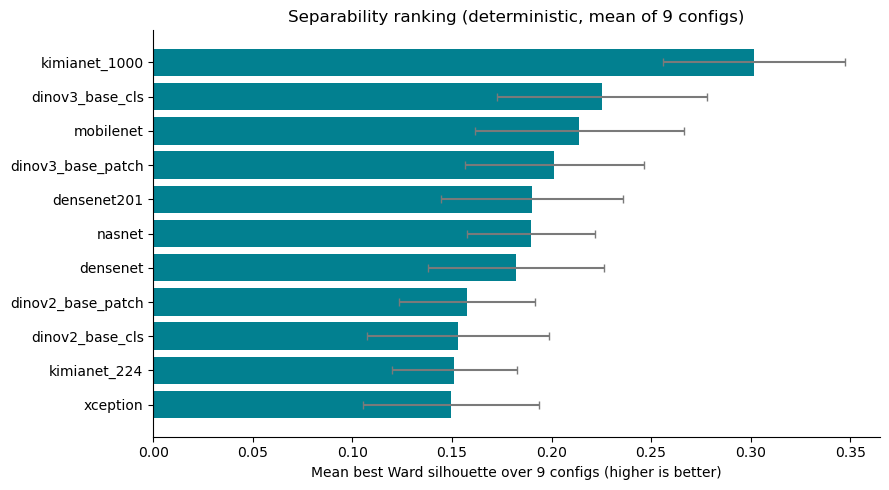

In [9]:
# bar chart of the mean Ward silhouette (the headline separability ranking)
d = agg.dropna(subset=["mean_ward_silhouette"]).sort_values("mean_ward_silhouette")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(d["backbone"], d["mean_ward_silhouette"], xerr=d["std_ward_silhouette"],
        color="#028090", ecolor="#7a7a7a", capsize=3)
ax.set_xlabel("Mean best Ward silhouette over 9 configs (higher is better)")
ax.set_title("Separability ranking (deterministic, mean of 9 configs)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "separability_ranking_meanOf9.png", dpi=150, bbox_inches="tight")
plt.show()

### 4c. No-PCA control

Same Ward + HDBSCAN probe on the **full (normalized) space**, without PCA. Expect the
silhouette to collapse (curse of dimensionality) and HDBSCAN to find no structure — this is
what justifies using PCA before clustering.

In [10]:
control_rows = []
for name, X in embeddings.items():
    for norm in SWEEP_NORMALIZATIONS:
        Xp = preprocess(X, normalization=norm, pca_n=SWEEP_PCA_CONTROL)  # full space
        row = {"backbone": name, "normalization": norm, "pca_n_components": 0}
        row.update(separability_for_space(Xp))
        control_rows.append(row)
    print(f"  control done {name}")

control_df = pd.DataFrame(control_rows)
control_df.to_csv(RESULTS_DIR / "separability_noPCA_control.csv", index=False)

print("Mean best Ward silhouette WITH PCA  (9 configs):",
      round(float(separability_sweep["ward_best_silhouette"].mean()), 4))
print("Mean best Ward silhouette NO  PCA   (control) :",
      round(float(control_df["ward_best_silhouette"].mean()), 4))
control_df

c:\Users\alexa\Desktop\Glomeruli-FP03-2026\src\metrics\deterministic_separability.py:524: RuntimeWarning: overflow encountered in power
  inv = D ** (-n_features)
c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


  control done densenet201
  control done densenet


c:\Users\alexa\Desktop\Glomeruli-FP03-2026\src\metrics\deterministic_separability.py:524: RuntimeWarning: overflow encountered in power
  inv = D ** (-n_features)


  control done dinov2_base_cls
  control done dinov2_base_patch


c:\Users\alexa\Desktop\Glomeruli-FP03-2026\src\metrics\deterministic_separability.py:524: RuntimeWarning: overflow encountered in power
  inv = D ** (-n_features)
c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


...

c:\Users\alexa\Desktop\Glomeruli-FP03-2026\src\metrics\deterministic_separability.py:524: RuntimeWarning: overflow encountered in power
  inv = D ** (-n_features)


  control done kimianet_1000


c:\Users\alexa\Desktop\Glomeruli-FP03-2026\src\metrics\deterministic_separability.py:524: RuntimeWarning: overflow encountered in power
  inv = D ** (-n_features)
c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


  control done kimianet_224
  control done mobilenet
  control done nasnet
  control done xception
Mean best Ward silhouette WITH PCA  (9 configs): 0.1923
Mean best Ward silhouette NO  PCA   (control) : 0.0995


,backbone,normalization,pca_n_components,ward_best_silhouette,ward_best_k,ward_best_davies_bouldin,hdbscan_best_dbcv,hdbscan_best_dbcv_n_clusters,hdbscan_min_noise_fraction
0,densenet201,standard,0,0.070608,2,2.780513,NaN,NaN,1.000000
1,densenet201,l2,0,0.089439,2,2.977591,0.032462,2.0,0.480059
2,densenet201,none,0,0.090133,2,2.953389,NaN,NaN,1.000000
3,densenet,standard,0,0.069218,2,3.094690,NaN,NaN,1.000000
4,densenet,l2,0,0.088940,2,2.762633,NaN,NaN,1.000000
5,densenet,none,0,0.086443,2,2.835228,NaN,NaN,1.000000
6,dinov2_base_cls,standard,0,0.073044,2,2.612317,0.010525,2.0,0.852290
7,dinov2_base_cls,l2,0,0.079364,2,2.470592,-0.020511,2.0,0.840473
8,dinov2_base_cls,none,0,0.075709,2,2.562396,0.013484,2.0,0.844904
9,dinov2_base_patch,standard,0,0.076391,3,2.544217,NaN,NaN,1.000000


## 5. Continuous gradation *(optional)*

How well each embedding space aligns with a **continuous morphological severity gradient**
(H&E + texture proxy from the crops), rather than forming discrete clusters. Requires
`crops/` and `masks/`; it reads every image, so it is slower. Deterministic (`random_state=42`).

In [11]:
RUN_GRADATION = True  # set False to skip

if RUN_GRADATION:
    from src.metrics.morphology_descriptors import build_morphology_matrix, morphology_severity_axis
    from src.metrics.continuous_gradation import evaluate_gradation

    image_paths = sorted(p for p in CROPS_DIR.iterdir() if p.suffix.lower() == ".png")
    mask_lookup = {p.stem.replace("_mask", ""): p for p in MASKS_DIR.iterdir()
                   if MASKS_DIR.is_dir() and p.suffix.lower() == ".png"}
    mask_paths = [mask_lookup.get(img.stem) for img in image_paths] if mask_lookup else None

    print(f"Extracting morphology from {len(image_paths)} crops...")
    morph_matrix, feat_names = build_morphology_matrix(image_paths, mask_paths)
    morphology_score = morphology_severity_axis(morph_matrix, random_state=RANDOM_STATE)

    pd.DataFrame({"crop": [p.name for p in image_paths],
                  "morphology_score": morphology_score}).to_csv(
        RESULTS_DIR / "morphology_scores.csv", index=False)

    grad_rows = []
    for name, X in embeddings.items():
        if X.shape[0] != len(morphology_score):
            print(f"  [SKIP] {name}: {X.shape[0]} rows != {len(morphology_score)} crops")
            continue
        Xp = preprocess(X)
        m = evaluate_gradation(Xp, morphology_score, k=K_NEIGHBORS, random_state=RANDOM_STATE)
        m["backbone"] = name
        grad_rows.append(m)

    gradation_df = pd.DataFrame(grad_rows).sort_values("grad_distance_morph_corr", ascending=False)
    gradation_df.to_csv(RESULTS_DIR / "gradation.csv", index=False)
    display(gradation_df)
else:
    gradation_df = None
    print("Gradation skipped.")

Extracting morphology from 677 crops...


,grad_distance_morph_corr,grad_neighborhood_consistency,grad_gradient_smoothness_moran,backbone
1,0.309387,0.069346,0.394330,densenet
3,0.295214,0.038759,0.333324,dinov2_base_patch
8,0.275198,0.142981,0.405850,mobilenet
5,0.272182,0.113852,0.375567,dinov3_base_patch
0,0.268902,0.104696,0.405894,densenet201
4,0.214956,0.076270,0.360311,dinov3_base_cls
10,0.197183,-0.015098,0.314983,xception
2,0.192637,-0.033623,0.277432,dinov2_base_cls
7,0.176166,-0.083986,0.255445,kimianet_224
9,0.131056,-0.083754,0.289815,nasnet


## 5b. Decision metrics across the 9 configurations *(robustness)*

Section 5 computes gradation at the **reference** preprocessing (L2 + PCA 10, the space used by
the clustering pipeline). But at the backbone-selection stage the preprocessing is not yet
fixed, and gradation is now the **primary decision criterion**. So — exactly like separability
in Section 4 — we sweep gradation over the **same 9 configurations** (3 normalizations × PCA
5/10/20) and check whether the ranking is robust. Hopkins / NN are swept too, for completeness
(they are descriptive, not decisional).

In [12]:
from src.metrics.continuous_gradation import evaluate_gradation

GRAD_METRICS = ["grad_distance_morph_corr",
                "grad_neighborhood_consistency",
                "grad_gradient_smoothness_moran"]

if "morphology_score" in globals():
    grad_sweep_rows = []
    for name, X in embeddings.items():
        if X.shape[0] != len(morphology_score):
            continue
        for norm in SWEEP_NORMALIZATIONS:
            for pca_n in SWEEP_PCA_COMPONENTS:
                Xp = preprocess(X, normalization=norm, pca_n=pca_n)
                m = evaluate_gradation(Xp, np.asarray(morphology_score),
                                       k=K_NEIGHBORS, random_state=RANDOM_STATE)
                grad_sweep_rows.append({"backbone": name, "normalization": norm,
                                        "pca_n_components": pca_n,
                                        "config": f"{norm}+pca{pca_n}", **m})
        print(f"  grad-sweep done {name}")
    gradation_sweep = pd.DataFrame(grad_sweep_rows)
    gradation_sweep.to_csv(RESULTS_DIR / "gradation_sweep_9configs.csv", index=False)
    display(gradation_sweep.head())
else:
    gradation_sweep = None
    print("Run Section 5 first (needs morphology_score).")

c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Exception in thread Thread-213 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\subprocess.py", line 1515, in _readerthread
    buffer

  grad-sweep done densenet201
  grad-sweep done densenet
  grad-sweep done dinov2_base_cls
  grad-sweep done dinov2_base_patch
  grad-sweep done dinov3_base_cls
  grad-sweep done dinov3_base_patch
  grad-sweep done kimianet_1000
  grad-sweep done kimianet_224
  grad-sweep done mobilenet
  grad-sweep done nasnet
  grad-sweep done xception


,backbone,normalization,pca_n_components,config,grad_distance_morph_corr,grad_neighborhood_consistency,grad_gradient_smoothness_moran
0,densenet201,standard,5,standard+pca5,0.262032,0.151436,0.400211
1,densenet201,standard,10,standard+pca10,0.292896,0.167313,0.416761
2,densenet201,standard,20,standard+pca20,0.309965,0.178169,0.386964
3,densenet201,l2,5,l2+pca5,0.244421,0.050428,0.365648
4,densenet201,l2,10,l2+pca10,0.268902,0.104696,0.405894


In [13]:
if gradation_sweep is not None:
    agg = gradation_sweep.groupby("backbone")[GRAD_METRICS].agg(["mean", "std"])
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    grad_rank = agg.reset_index().sort_values("grad_neighborhood_consistency_mean", ascending=False)
    grad_rank.to_csv(RESULTS_DIR / "gradation_ranking_meanOf9.csv", index=False)

    print("Times ranked #1 across the 9 configs (robustness of the ordering):")
    for m in GRAD_METRICS:
        w = gradation_sweep.loc[gradation_sweep.groupby("config")[m].idxmax(), "backbone"].value_counts()
        print(f"  {m}: " + ", ".join(f"{b}x{c}" for b, c in w.items()))
    display(grad_rank)

Times ranked #1 across the 9 configs (robustness of the ordering):
  grad_distance_morph_corr: densenetx7, dinov2_base_patchx2
  grad_neighborhood_consistency: mobilenetx4, kimianet_1000x3, dinov3_base_patchx2
  grad_gradient_smoothness_moran: mobilenetx5, densenetx3, densenet201x1


,backbone,grad_distance_morph_corr_mean,grad_distance_morph_corr_std,grad_neighborhood_consistency_mean,grad_neighborhood_consistency_std,grad_gradient_smoothness_moran_mean,grad_gradient_smoothness_moran_std
8,mobilenet,0.268802,0.009978,0.134794,0.021725,0.399208,0.011372
1,densenet201,0.267664,0.022814,0.110761,0.046121,0.390644,0.016413
6,kimianet_1000,0.153619,0.062141,0.101946,0.080937,0.356811,0.025199
0,densenet,0.303044,0.019109,0.096150,0.039323,0.404248,0.017598
5,dinov3_base_patch,0.261543,0.021946,0.085450,0.049963,0.354107,0.021916
4,dinov3_base_cls,0.207418,0.016675,0.058001,0.024987,0.347732,0.014748
3,dinov2_base_patch,0.291541,0.016950,0.035000,0.050838,0.332075,0.037479
10,xception,0.196542,0.023204,-0.028922,0.075083,0.299172,0.028235
2,dinov2_base_cls,0.179857,0.027109,-0.055596,0.079678,0.257753,0.048620
7,kimianet_224,0.139293,0.073484,-0.057754,0.111645,0.290258,0.056391


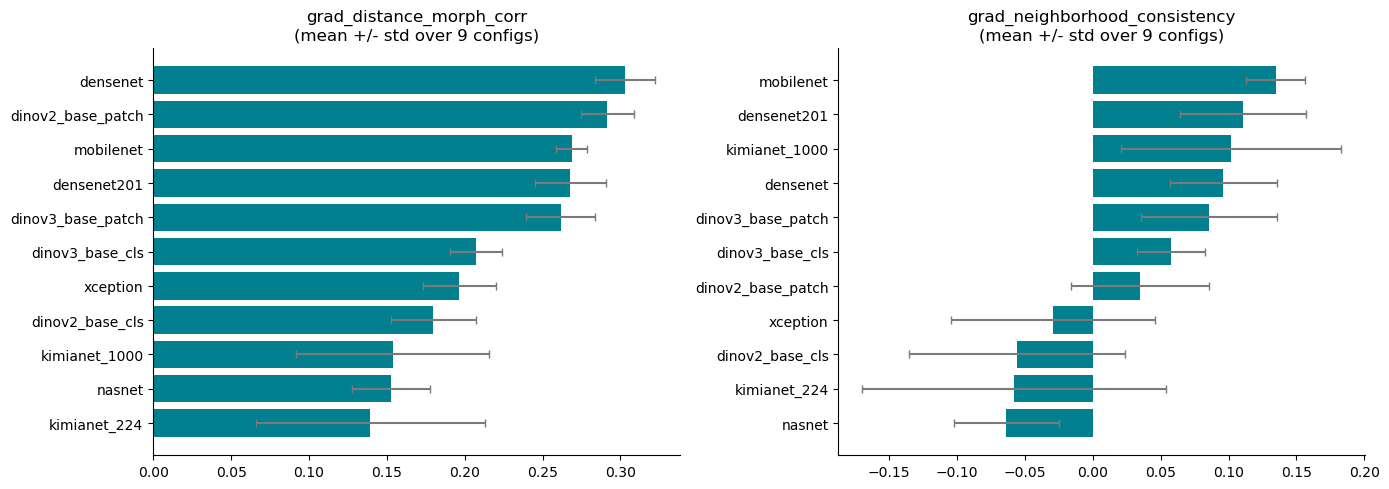

In [14]:
if gradation_sweep is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, m in zip(axes, ["grad_distance_morph_corr", "grad_neighborhood_consistency"]):
        d = grad_rank.sort_values(f"{m}_mean")
        ax.barh(d["backbone"], d[f"{m}_mean"], xerr=d[f"{m}_std"],
                color="#028090", ecolor="#7a7a7a", capsize=3)
        ax.set_title(f"{m}\n(mean +/- std over 9 configs)")
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "gradation_sweep_9configs.png", dpi=150, bbox_inches="tight")
    plt.show()

### 5b (support) — Hopkins and nearest-neighbor geometry across the 9 configs

Descriptive geometry metrics swept for completeness. These do not drive the backbone choice, so
the ranking here is only informative; the decision rests on separability (4) and gradation (5b).

In [15]:
from src.metrics.hopkins import compute_hopkins_dataframe
from src.metrics.nearest_neighbor import evaluate_embedding_backbone

geom_rows = []
for name, X in embeddings.items():
    for norm in SWEEP_NORMALIZATIONS:
        for pca_n in SWEEP_PCA_COMPONENTS:
            Xp = preprocess(X, normalization=norm, pca_n=pca_n)
            row = {"backbone": name, "normalization": norm, "pca_n_components": pca_n,
                   "config": f"{norm}+pca{pca_n}"}
            try:
                h = compute_hopkins_dataframe(Xp, n_runs=50, random_state=RANDOM_STATE)
                row["hopkins_mean"] = float(h["hopkins_mean"].iloc[0])
            except Exception:
                row["hopkins_mean"] = np.nan
            try:
                nnd = evaluate_embedding_backbone(Xp)
                for c in nnd.columns:
                    row[c] = float(nnd[c].iloc[0])
            except Exception:
                pass
            geom_rows.append(row)
    print(f"  geometry-sweep done {name}")

geometry_sweep = pd.DataFrame(geom_rows)
geometry_sweep.to_csv(RESULTS_DIR / "geometry_sweep_9configs.csv", index=False)
cols = [c for c in ["hopkins_mean", "MNN@10", "hubness skew"] if c in geometry_sweep.columns]
geom_agg = (geometry_sweep.groupby("backbone")[cols].mean()
            .reset_index().sort_values("hopkins_mean", ascending=False))
geom_agg.to_csv(RESULTS_DIR / "geometry_ranking_meanOf9.csv", index=False)
display(geom_agg)

  geometry-sweep done densenet201
  geometry-sweep done densenet
  geometry-sweep done dinov2_base_cls
  geometry-sweep done dinov2_base_patch
  geometry-sweep done dinov3_base_cls
  geometry-sweep done dinov3_base_patch
  geometry-sweep done kimianet_1000
  geometry-sweep done kimianet_224
  geometry-sweep done mobilenet
  geometry-sweep done nasnet
  geometry-sweep done xception


,backbone,hopkins_mean,MNN@10,hubness skew
6,kimianet_1000,0.731810,0.665321,0.450653
8,mobilenet,0.729077,0.664139,0.624538
3,dinov2_base_patch,0.726075,0.704842,0.470595
7,kimianet_224,0.723393,0.690694,0.434309
1,densenet201,0.720262,0.688232,0.412789
4,dinov3_base_cls,0.720209,0.684589,0.514481
2,dinov2_base_cls,0.719173,0.703857,0.358386
9,nasnet,0.718847,0.666896,0.359625
10,xception,0.711394,0.675595,0.622271
5,dinov3_base_patch,0.710418,0.703824,0.453548


## 6. 2D visualization — PCA **and** UMAP *(optional)*

Projects one backbone to 2D with **both** PCA and UMAP, side by side, colored by severity.

**Important — order of execution.** UMAP conflicts with TensorFlow's native libraries on
Windows. Sections 1–6 do **not** import TensorFlow; Section 7 (invariance) does. So:
**restart the kernel, run sections 1–6 first (UMAP works here), and run Section 7 LAST.**
Once TensorFlow is loaded, UMAP fails for the rest of the kernel session and this cell shows
PCA only. UMAP is just for the picture — it is **not** part of the deterministic evaluation.

c:\Users\alexa\miniconda3\envs\glomeruli-fp03\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: OK
PCA and UMAP identical? False (should be False)


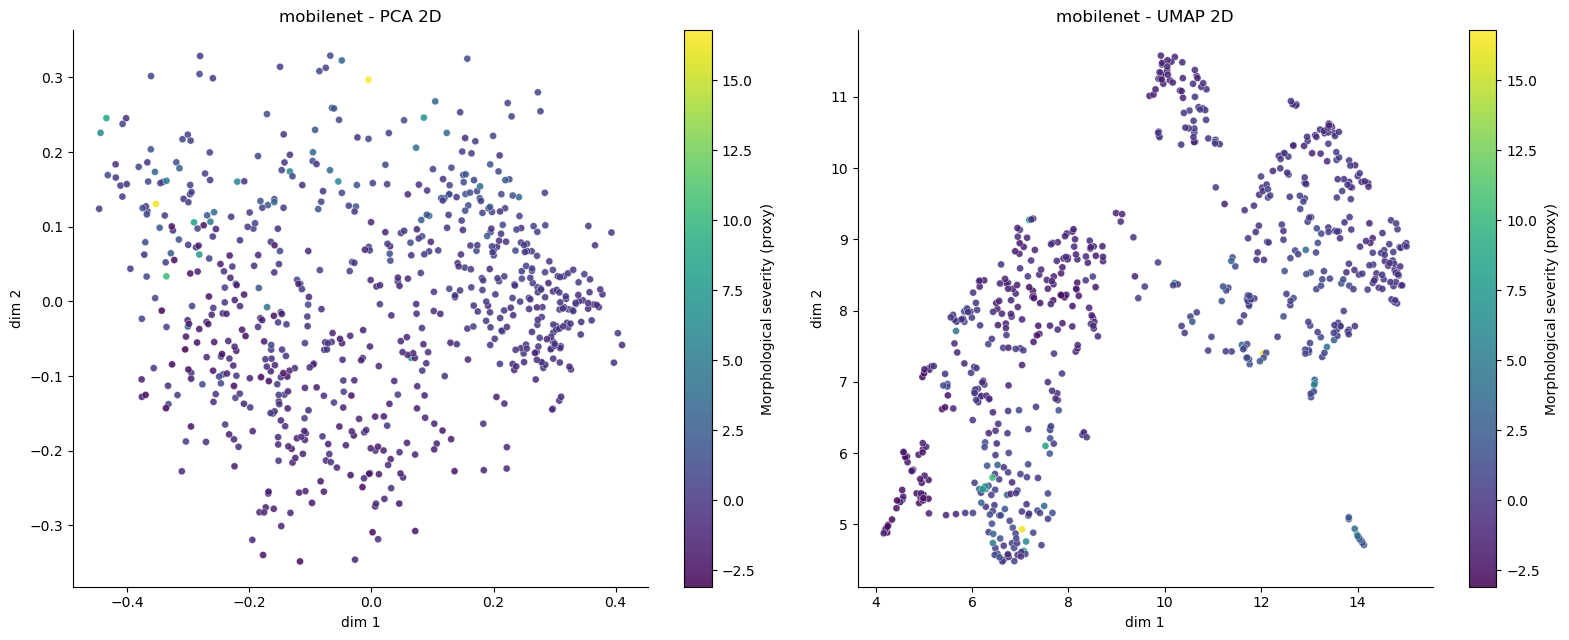

In [16]:
import sys, types

VIZ_BACKBONE     = "mobilenet"
VIZ_METHODS      = ["pca", "umap"]   # choose: ["pca"] | ["umap"] | ["pca", "umap"]
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST    = 0.1

if VIZ_BACKBONE in embeddings and (RESULTS_DIR / "morphology_scores.csv").exists():
    scores = pd.read_csv(RESULTS_DIR / "morphology_scores.csv")["morphology_score"].to_numpy()
    X = embeddings[VIZ_BACKBONE]

    if X.shape[0] != len(scores):
        print("Embedding/scores length mismatch.")
    else:
        Xn = normalize(X, norm="l2", axis=1) if NORMALIZATION == "l2" else X
        Xr = PCA(n_components=min(50, Xn.shape[0] - 1),
                 random_state=RANDOM_STATE).fit_transform(Xn)

        projections = {}   # {method_name: 2D coords}, computed only for what you asked
        if "pca" in VIZ_METHODS:
            projections["PCA"] = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xr)

        if "umap" in VIZ_METHODS:
            try:
                # umap/__init__.py eagerly imports parametric_umap -> torch, which is broken
                # in this env (WinError 127). parametric UMAP is not needed, so we register a
                # dummy module BEFORE importing umap, so 'import torch' is never triggered.
                if "umap.parametric_umap" not in sys.modules:
                    _stub = types.ModuleType("umap.parametric_umap")
                    _stub.ParametricUMAP = None
                    _stub.load_ParametricUMAP = None
                    sys.modules["umap.parametric_umap"] = _stub
                from umap.umap_ import UMAP  # core algorithm, no torch/TF
                projections["UMAP"] = UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                                           min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE).fit_transform(Xr)
                print("UMAP: OK")
            except Exception as e:
                import traceback
                print(f"[WARN] UMAP unavailable ({type(e).__name__}) - skipping it. Traceback:")
                traceback.print_exc()

        if not projections:
            print("Nothing to plot: check VIZ_METHODS (or UMAP failed).")
        else:
            ncols = len(projections)
            fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 6.5), squeeze=False)
            for ax, (mname, coords) in zip(axes[0], projections.items()):
                sc = ax.scatter(coords[:, 0], coords[:, 1], c=scores, cmap="viridis",
                                s=26, alpha=0.85, edgecolors="white", linewidths=0.3)
                fig.colorbar(sc, ax=ax, label="Morphological severity (proxy)")
                ax.set_title(f"{VIZ_BACKBONE} - {mname} 2D")
                ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
                ax.spines[["top", "right"]].set_visible(False)
            if {"PCA", "UMAP"}.issubset(projections):
                print("PCA and UMAP identical?",
                      np.allclose(projections["PCA"], projections["UMAP"]), "(should be False)")
            fig.tight_layout()
            tag = "_".join(m.lower() for m in projections)
            fig.savefig(FIG_DIR / f"viz2d_{VIZ_BACKBONE}_{tag}.png", dpi=150, bbox_inches="tight")
            plt.show()
else:
    print("Run section 5 first (needs morphology_scores.csv), or pick a valid backbone.")

## 7. Augmentation invariance *(optional, heavy)*

**Run this section LAST.** It imports TensorFlow (via the backbones); once TF is loaded, UMAP
in Section 6 will fail for the rest of the kernel session. So do the 2D UMAP plot first.

Robustness of each backbone to rotations / flips (a glomerulus crop has no natural
orientation). This is the **only** section that re-runs the backbones, so it needs
TensorFlow + `keras_hub` + the model weights and is slow. Set `RUN_INVARIANCE = False` to skip.

Metrics are computed exactly like `evaluate_backbone_invariance.py`: `self-retrieval@{5,10,20}`
and the median intra/nearest-inter ratio, deterministic (`random_state=42`).

Only the backbones registered in that script are included (`densenet169`, `densenet201`,
`mobilenet`, `xception`, `nasnet`); DINOv2/v3 and KimiaNet were not part of the invariance
registry.

In [17]:
RUN_INVARIANCE    = True    # heavy: TensorFlow + backbone weights + inference on crops
INVARIANCE_SUBSET = 200     # crops sampled (0 = all, very costly)
INVARIANCE_BACKBONES = ["densenet169", "densenet201", "mobilenet", "xception", "nasnet"]

if RUN_INVARIANCE:
    from src.metrics.augmentation_invariance import compute_augmentation_robustness_metrics
    from src.backbones.densenet169 import DenseNet169
    from src.backbones.densenet201 import DenseNet201
    from src.backbones.mobilenet import MobileNet
    from src.backbones.xception import Xception
    from src.backbones.nasnet import NASNet

    # input sizes match the BACKBONE_REGISTRY defaults of evaluate_backbone_invariance.py
    BACKBONE_BUILDERS = {
        "densenet169": lambda: DenseNet169(224),
        "densenet201": lambda: DenseNet201(224),
        "mobilenet":   lambda: MobileNet(224),
        "xception":    lambda: Xception(299),
        "nasnet":      lambda: NASNet(331),
    }

    crops = sorted(p for p in CROPS_DIR.iterdir() if p.suffix.lower() == ".png")
    if MASKS_DIR.is_dir():
        mask_lookup = {p.stem.replace("_mask", ""): p for p in MASKS_DIR.iterdir()
                       if p.suffix.lower() == ".png"}
        masks = [mask_lookup.get(c.stem) for c in crops]
        masks = masks if all(m is not None for m in masks) else None
        if masks is None:
            print("  [INFO] some masks missing: running invariance without masks.")
    else:
        masks = None

    inv_rows = []
    for bb in INVARIANCE_BACKBONES:
        print(f"  invariance: {bb} ...")
        model = BACKBONE_BUILDERS[bb]()
        embed_fn = lambda image, mask, _m=model: _m(image, mask)  # _m avoids late binding
        res = compute_augmentation_robustness_metrics(
            image_paths=crops,
            embed_fn=embed_fn,
            mask_paths=masks,
            subset_size=(INVARIANCE_SUBSET or None),
            random_state=RANDOM_STATE,
        )
        row = {"backbone": bb}
        row.update(res["overall"].iloc[0].to_dict())
        inv_rows.append(row)

    invariance_df = pd.DataFrame(inv_rows).sort_values("self-retrieval@5", ascending=False)
    invariance_df.to_csv(RESULTS_DIR / "augmentation_invariance.csv", index=False)
    display(invariance_df)
else:
    invariance_df = None
    print("Invariance skipped.")

  invariance: densenet169 ...
  invariance: densenet201 ...
  invariance: mobilenet ...
  invariance: xception ...
  invariance: nasnet ...


,backbone,median intra/nearest-inter ratio,self-retrieval@5,self-retrieval@10,self-retrieval@20
1,densenet201,0.631522,0.998,1.000,1.000
3,xception,0.626312,0.995,0.999,1.000
0,densenet169,0.618054,0.993,0.996,1.000
2,mobilenet,0.711211,0.993,0.995,0.999
4,nasnet,0.565580,0.986,0.997,0.999


## 8. Summary table

Standard metrics side by side (no aggregated score). Separability here is the **mean over the
9 configs**. The invariance table uses different backbone names (`densenet169` vs `densenet`),
so it is saved separately rather than merged.

In [18]:
frames = []
for path, cols in [
    ("hopkins.csv", ["backbone", "hopkins_mean"]),
    ("nearest_neighbor_metrics.csv", None),
    ("separability_ranking_meanOf9.csv",
     ["backbone", "mean_ward_silhouette", "mean_hdbscan_dbcv", "mean_min_noise"]),
    ("gradation.csv", None),
]:
    p = RESULTS_DIR / path
    if p.exists():
        df = pd.read_csv(p)
        if cols:
            df = df[[c for c in cols if c in df.columns]]
        frames.append(df.set_index("backbone"))

if frames:
    summary = pd.concat(frames, axis=1).reset_index()
    summary.to_csv(RESULTS_DIR / "SUMMARY.csv", index=False)
    print("Saved:", RESULTS_DIR / "SUMMARY.csv")
    display(summary)
else:
    print("No result files found yet - run the sections above.")

Saved: c:\Users\alexa\Desktop\Glomeruli-FP03-2026\results\backbone_evaluation\SUMMARY.csv


,backbone,hopkins_mean,MNN@5,MNN@10,MNN@20,hubness skew,max hubness,mean_ward_silhouette,mean_hdbscan_dbcv,mean_min_noise,grad_distance_morph_corr,grad_neighborhood_consistency,grad_gradient_smoothness_moran
0,dinov2_base_patch,0.736859,0.653471,0.693353,0.725849,0.423640,26.0,0.157476,-0.161762,0.827015,0.295214,0.038759,0.333324
1,dinov3_base_cls,0.726521,0.652290,0.668538,0.700591,0.739742,30.0,0.225393,-0.090450,0.752339,0.214956,0.076270,0.360311
2,dinov2_base_cls,0.723480,0.662925,0.687445,0.723634,0.447732,28.0,0.152878,-0.091773,0.836205,0.192637,-0.033623,0.277432
3,dinov3_base_patch,0.714709,0.646381,0.683309,0.732201,0.472106,27.0,0.201455,-0.117205,0.750041,0.272182,0.113852,0.375567
4,mobilenet,0.713730,0.618612,0.653767,0.682866,0.797098,33.0,0.214012,-0.160695,0.786476,0.275198,0.142981,0.405850
5,kimianet_1000,0.707866,0.620384,0.641359,0.651846,0.446370,27.0,0.301714,-0.142246,0.664041,0.125780,0.087892,0.340050
6,densenet201,0.703324,0.633383,0.682422,0.719645,0.552641,28.0,0.190141,-0.126916,0.528311,0.268902,0.104696,0.405894
7,nasnet,0.691082,0.602068,0.648449,0.696898,0.382675,25.0,0.189526,-0.143367,0.648285,0.131056,-0.083754,0.289815
8,densenet,0.679909,0.632792,0.676219,0.701182,0.589198,26.0,0.182170,-0.121355,0.768915,0.309387,0.069346,0.394330
9,xception,0.671541,0.628065,0.663811,0.707386,0.581478,27.0,0.149313,-0.073360,0.823896,0.197183,-0.015098,0.314983


## 9. Additional deterministic evaluations

The sections below strengthen the backbone choice. They are all deterministic (fixed seeds)
and reuse the same modules. Several depend on Section 5 having run (they need
`morphology_score` / `morph_matrix` / `image_paths`).

### 9.1 Error bars on the gradation ranking (bootstrap)

The leads between backbones are small, so we quantify uncertainty. We recompute the three
gradation metrics on many random **subsamples** (m-out-of-n, no replacement → no zero-distance
duplicates) and report mean + 95% interval. **Overlapping intervals ⇒ backbones are
statistically indistinguishable** on that metric.

In [19]:
from src.metrics.continuous_gradation import evaluate_gradation

RUN_BOOTSTRAP = True
BOOT_REPS     = 100     # lower this if too slow
BOOT_FRACTION = 0.8     # fraction of glomeruli per subsample
BOOT_METRICS  = ["grad_distance_morph_corr",
                 "grad_neighborhood_consistency",
                 "grad_gradient_smoothness_moran"]

if RUN_BOOTSTRAP and ("morphology_score" in globals()):
    n = len(morphology_score)
    m = max(50, int(BOOT_FRACTION * n))
    boot_rows = []
    for name, X in embeddings.items():
        if X.shape[0] != n:
            continue
        Xp = preprocess(X)
        acc = {mm: [] for mm in BOOT_METRICS}
        for r in range(BOOT_REPS):
            rng = np.random.default_rng(1000 + r)   # fixed seeds -> reproducible
            idx = rng.choice(n, size=m, replace=False)
            res = evaluate_gradation(Xp[idx], np.asarray(morphology_score)[idx],
                                     k=K_NEIGHBORS, random_state=RANDOM_STATE)
            for mm in BOOT_METRICS:
                acc[mm].append(res[mm])
        row = {"backbone": name}
        for mm in BOOT_METRICS:
            arr = np.asarray(acc[mm], dtype=float)
            row[f"{mm}_mean"] = float(np.nanmean(arr))
            row[f"{mm}_lo"]   = float(np.nanpercentile(arr, 2.5))
            row[f"{mm}_hi"]   = float(np.nanpercentile(arr, 97.5))
        boot_rows.append(row)
        print(f"  bootstrap done {name}")
    bootstrap_df = pd.DataFrame(boot_rows).sort_values(
        "grad_distance_morph_corr_mean", ascending=False)
    bootstrap_df.to_csv(RESULTS_DIR / "gradation_bootstrap_ci.csv", index=False)
    display(bootstrap_df)
else:
    bootstrap_df = None
    print("Bootstrap skipped (run Section 5 first to build morphology_score).")

  bootstrap done densenet201
  bootstrap done densenet
  bootstrap done dinov2_base_cls
  bootstrap done dinov2_base_patch
  bootstrap done dinov3_base_cls
  bootstrap done dinov3_base_patch
  bootstrap done kimianet_1000
  bootstrap done kimianet_224
  bootstrap done mobilenet
  bootstrap done nasnet
  bootstrap done xception


,backbone,grad_distance_morph_corr_mean,grad_distance_morph_corr_lo,grad_distance_morph_corr_hi,grad_neighborhood_consistency_mean,grad_neighborhood_consistency_lo,grad_neighborhood_consistency_hi,grad_gradient_smoothness_moran_mean,grad_gradient_smoothness_moran_lo,grad_gradient_smoothness_moran_hi
1,densenet,0.304425,0.286803,0.318986,0.054376,0.027055,0.093020,0.377977,0.347053,0.436884
3,dinov2_base_patch,0.294673,0.271717,0.313455,0.016353,-0.024348,0.060118,0.307640,0.267514,0.370230
8,mobilenet,0.272928,0.256505,0.288587,0.121451,0.096116,0.167549,0.389196,0.356971,0.450841
5,dinov3_base_patch,0.272778,0.251693,0.290170,0.090187,0.060905,0.125284,0.350499,0.315135,0.411043
0,densenet201,0.264772,0.247997,0.282073,0.082321,0.056829,0.110364,0.380229,0.343502,0.437998
4,dinov3_base_cls,0.213297,0.193308,0.231876,0.048460,0.021956,0.075905,0.342028,0.310221,0.396160
10,xception,0.190806,0.176107,0.203144,-0.033011,-0.064861,0.017084,0.303372,0.272670,0.348462
2,dinov2_base_cls,0.187273,0.166206,0.208125,-0.059312,-0.089063,-0.030666,0.267556,0.239185,0.318932
7,kimianet_224,0.170874,0.154481,0.192519,-0.096429,-0.123891,-0.066709,0.243425,0.211184,0.285578
9,nasnet,0.126157,0.113726,0.143252,-0.097450,-0.123428,-0.067134,0.271671,0.233435,0.313991


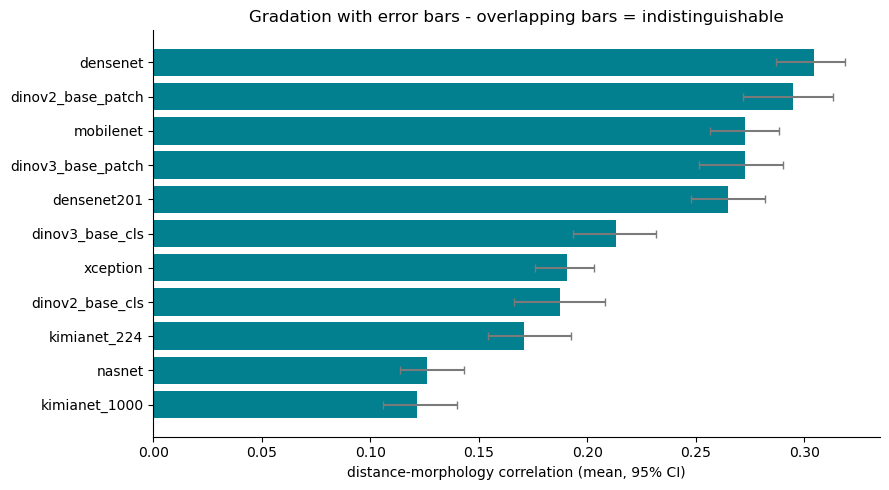

In [20]:
if bootstrap_df is not None:
    d = bootstrap_df.sort_values("grad_distance_morph_corr_mean")
    lo = d["grad_distance_morph_corr_mean"] - d["grad_distance_morph_corr_lo"]
    hi = d["grad_distance_morph_corr_hi"] - d["grad_distance_morph_corr_mean"]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(d["backbone"], d["grad_distance_morph_corr_mean"],
            xerr=np.vstack([lo, hi]), color="#028090", ecolor="#7a7a7a", capsize=3)
    ax.set_xlabel("distance-morphology correlation (mean, 95% CI)")
    ax.set_title("Gradation with error bars - overlapping bars = indistinguishable")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "gradation_bootstrap_distcorr.png", dpi=150, bbox_inches="tight")
    plt.show()

### 9.2 Slide / batch confounding on the embeddings (label-free)

Biggest risk: the space is organized by **source slide / stain** rather than biology. For each
glomerulus we measure how many of its k nearest neighbors come from the **same slide**, versus
the fraction expected by chance. `enrichment ≈ 1` = no batch effect; `enrichment ≫ 1` =
neighbors dominated by the same slide (artefact).

**Adapt `slide_id_from_filename` to your crop naming scheme** — the default takes everything
before the last underscore.

In [21]:
from sklearn.neighbors import NearestNeighbors

RUN_SLIDE_CONFOUND = True

def slide_id_from_filename(fname: str) -> str:
    # ADAPT to your naming scheme. Default: prefix before the last underscore.
    stem = Path(fname).stem
    return stem.rsplit("_", 1)[0] if "_" in stem else stem

if RUN_SLIDE_CONFOUND and CROPS_DIR.is_dir():
    crop_names = sorted(p.name for p in CROPS_DIR.iterdir() if p.suffix.lower() == ".png")
    slide_ids = np.array([slide_id_from_filename(n) for n in crop_names])
    n = len(slide_ids)
    n_slides = len(set(slide_ids.tolist()))

    _, counts = np.unique(slide_ids, return_counts=True)
    expected = float(np.sum(counts * (counts - 1)) / (n * (n - 1)))  # P(2 random distinct share slide)

    if n_slides < 2:
        print(f"[WARN] parsed only {n_slides} slide id(s): adapt slide_id_from_filename to your names.")

    rows = []
    for name, X in embeddings.items():
        if X.shape[0] != n:
            print(f"  [SKIP] {name}: {X.shape[0]} emb != {n} crops")
            continue
        Xp = preprocess(X)
        nn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(Xp)
        idx = nn.kneighbors(Xp, return_distance=False)[:, 1:]
        same = float(np.mean([np.mean(slide_ids[idx[i]] == slide_ids[i]) for i in range(n)]))
        rows.append({"backbone": name, "same_slide_frac_knn": same,
                     "expected_random": expected,
                     "enrichment": (same / expected) if expected > 0 else np.nan})
    slide_df = pd.DataFrame(rows).sort_values("enrichment")  # lower = less batch effect
    slide_df["n_slides"] = n_slides
    slide_df.to_csv(RESULTS_DIR / "slide_confound_embeddings.csv", index=False)
    print(f"Distinct slides parsed: {n_slides} | expected random same-slide frac = {expected:.3f}")
    print("enrichment ~1 = no batch effect; >>1 = neighbors dominated by the same slide.")
    display(slide_df)
else:
    slide_df = None
    print("Slide confound skipped.")

Distinct slides parsed: 9 | expected random same-slide frac = 0.128
enrichment ~1 = no batch effect; >>1 = neighbors dominated by the same slide.


,backbone,same_slide_frac_knn,expected_random,enrichment,n_slides
9,nasnet,0.254062,0.127621,1.990754,9
7,kimianet_224,0.268833,0.127621,2.106496,9
6,kimianet_1000,0.281733,0.127621,2.207577,9
10,xception,0.293353,0.127621,2.298627,9
2,dinov2_base_cls,0.311472,0.127621,2.440603,9
3,dinov2_base_patch,0.312654,0.127621,2.449862,9
1,densenet,0.313442,0.127621,2.456035,9
5,dinov3_base_patch,0.313836,0.127621,2.459122,9
0,densenet201,0.317381,0.127621,2.486900,9
4,dinov3_base_cls,0.328804,0.127621,2.576407,9


### 9.3 Validating the morphological proxy

No per-sample expert grading is available, so the proxy is validated **internally** (its
construct is grounded in established histological markers of glomerulosclerosis). Two checks:
1. **PC1 loadings** — is the severity axis interpretable (e.g. eosin/homogeneity up,
   hematoxylin down)?
2. **Leave-one-descriptor-out** — is the axis stable if any single descriptor is removed?

Note: the proxy is used as the **same identical reference for every backbone**, so any
imperfection applies equally to all and does not bias the *comparison* between backbones.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

if "morph_matrix" in globals() and "feat_names" in globals():
    Xm = np.asarray(morph_matrix, dtype=float)
    for j in range(Xm.shape[1]):
        col = Xm[:, j]
        if np.any(~np.isfinite(col)):
            med = np.nanmedian(col[np.isfinite(col)]) if np.any(np.isfinite(col)) else 0.0
            col[~np.isfinite(col)] = med
            Xm[:, j] = col
    Xstd = StandardScaler().fit_transform(Xm)
    pca1 = PCA(n_components=1, random_state=RANDOM_STATE).fit(Xstd)
    loadings = pd.DataFrame({
        "descriptor": feat_names,
        "pc1_loading": pca1.components_[0],
        "spearman_with_axis": [float(spearmanr(Xm[:, j], morphology_score).correlation)
                               for j in range(Xm.shape[1])],
    }).sort_values("pc1_loading", key=lambda s: s.abs(), ascending=False)
    print(f"PC1 explained variance of the morphology matrix: {pca1.explained_variance_ratio_[0]:.3f}")
    loadings.to_csv(RESULTS_DIR / "morphology_pc1_loadings.csv", index=False)
    display(loadings)
else:
    print("Run Section 5 first (needs morph_matrix, feat_names).")

PC1 explained variance of the morphology matrix: 0.385


,descriptor,pc1_loading,spearman_with_axis
1,eosin_hema_ratio,0.538723,0.876368
2,eosin_intensity,0.533514,0.836669
3,eosin_std,0.487013,0.810226
6,texture_energy,0.280931,0.652657
7,texture_homogeneity,0.246556,0.537309
4,hematoxylin_intensity,-0.180914,-0.450059
5,texture_contrast,-0.117543,-0.284702
0,area_fraction,0.041233,0.065870


In [23]:
from scipy.stats import spearmanr
from src.metrics.morphology_descriptors import morphology_severity_axis

if "morph_matrix" in globals() and "feat_names" in globals():
    loo_rows = []
    for j, fname in enumerate(feat_names):
        keep = [c for c in range(len(feat_names)) if c != j]
        axis_j = morphology_severity_axis(morph_matrix[:, keep], random_state=RANDOM_STATE)
        rho = abs(float(spearmanr(axis_j, morphology_score).correlation))  # sign irrelevant
        loo_rows.append({"dropped_descriptor": fname, "spearman_vs_full_axis": rho})
    loo_df = pd.DataFrame(loo_rows).sort_values("spearman_vs_full_axis")
    loo_df.to_csv(RESULTS_DIR / "morphology_axis_LOO_robustness.csv", index=False)
    print("Stability of the severity axis when each descriptor is removed (1.0 = unaffected):")
    display(loo_df)
else:
    print("Run Section 5 first.")

Stability of the severity axis when each descriptor is removed (1.0 = unaffected):


,dropped_descriptor,spearman_vs_full_axis
1,eosin_hema_ratio,0.762369
2,eosin_intensity,0.795155
3,eosin_std,0.895949
7,texture_homogeneity,0.928016
6,texture_energy,0.938997
4,hematoxylin_intensity,0.977065
5,texture_contrast,0.983805
0,area_fraction,0.999038


### 9.4 Cross-backbone consensus on the similarity structure

Do different backbones agree on **which glomeruli are similar**? For a fixed shared sample of
pairs we compute each backbone's pairwise distances, then the Spearman correlation between
backbones. A backbone whose structure agrees with the **consensus** of the others is capturing
shared (likely real) structure rather than idiosyncratic noise.

In [24]:
from scipy.stats import spearmanr

RUN_CONSENSUS   = True
CONSENSUS_PAIRS = 50000

if RUN_CONSENSUS:
    n = next(iter(embeddings.values())).shape[0]
    rng = np.random.default_rng(RANDOM_STATE)
    ia = rng.integers(0, n, size=CONSENSUS_PAIRS)
    ib = rng.integers(0, n, size=CONSENSUS_PAIRS)
    valid = ia != ib
    ia, ib = ia[valid], ib[valid]

    dist_vectors = {}
    for name, X in embeddings.items():
        if X.shape[0] != n:
            continue
        Xp = preprocess(X)
        dist_vectors[name] = np.linalg.norm(Xp[ia] - Xp[ib], axis=1)

    names = list(dist_vectors.keys())
    M = np.eye(len(names))
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            rho = float(spearmanr(dist_vectors[names[i]], dist_vectors[names[j]]).correlation)
            M[i, j] = M[j, i] = rho
    consensus = pd.DataFrame(M, index=names, columns=names)
    consensus.to_csv(RESULTS_DIR / "cross_backbone_distance_agreement.csv")

    agree = pd.DataFrame({
        "backbone": names,
        "mean_agreement_with_others": [(M[i].sum() - 1) / (len(names) - 1) for i in range(len(names))],
    }).sort_values("mean_agreement_with_others", ascending=False)
    agree.to_csv(RESULTS_DIR / "cross_backbone_agreement_ranking.csv", index=False)
    print("Agreement of each backbone's similarity structure with the consensus (higher = more shared structure):")
    display(agree)
else:
    print("Consensus skipped.")

Agreement of each backbone's similarity structure with the consensus (higher = more shared structure):


,backbone,mean_agreement_with_others
8,mobilenet,0.591654
4,dinov3_base_cls,0.585801
1,densenet,0.575118
5,dinov3_base_patch,0.574632
0,densenet201,0.567355
3,dinov2_base_patch,0.533028
2,dinov2_base_cls,0.495177
10,xception,0.462162
9,nasnet,0.423115
6,kimianet_1000,0.386594


### 9.5 Effective dimensionality / participation ratio

How concentrated is each embedding? A low participation ratio / few PCA components for 90-99%
variance means a more structured (less spread-out) space. Computed on the standardized full
space via `effective_dimensionality`.

In [25]:
from src.metrics.deterministic_separability import effective_dimensionality
from sklearn.preprocessing import StandardScaler

dim_rows = []
for name, X in embeddings.items():
    Xs = StandardScaler().fit_transform(X)
    info = effective_dimensionality(Xs, random_state=RANDOM_STATE)
    dim_rows.append({
        "backbone": name,
        "n_features": info["n_features"],
        "participation_ratio": info["participation_ratio"],
        "n_comp_var90": info.get("n_components_var90"),
        "n_comp_var95": info.get("n_components_var95"),
        "n_comp_var99": info.get("n_components_var99"),
    })
effdim_df = pd.DataFrame(dim_rows).sort_values("participation_ratio")
effdim_df.to_csv(RESULTS_DIR / "effective_dimensionality.csv", index=False)
display(effdim_df)

,backbone,n_features,participation_ratio,n_comp_var90,n_comp_var95,n_comp_var99
6,kimianet_1000,1024,9.689214,56,111,270
2,dinov2_base_cls,768,18.033929,71,122,267
3,dinov2_base_patch,768,20.298444,75,130,284
5,dinov3_base_patch,768,26.614417,96,157,312
4,dinov3_base_cls,768,26.783732,105,169,327
7,kimianet_224,1024,29.240010,134,217,403
0,densenet201,1920,35.671537,218,329,529
1,densenet,1664,35.829489,218,325,521
9,nasnet,4032,53.056998,244,350,536
8,mobilenet,1024,58.478420,264,357,521


### 9.6 Nearest-neighbor image grids *(qualitative)*

For a chosen backbone, show a few query glomeruli and their nearest neighbors (cosine). Are the
neighbors morphologically coherent? This is the qualitative counterpart of the numeric NN
metrics.

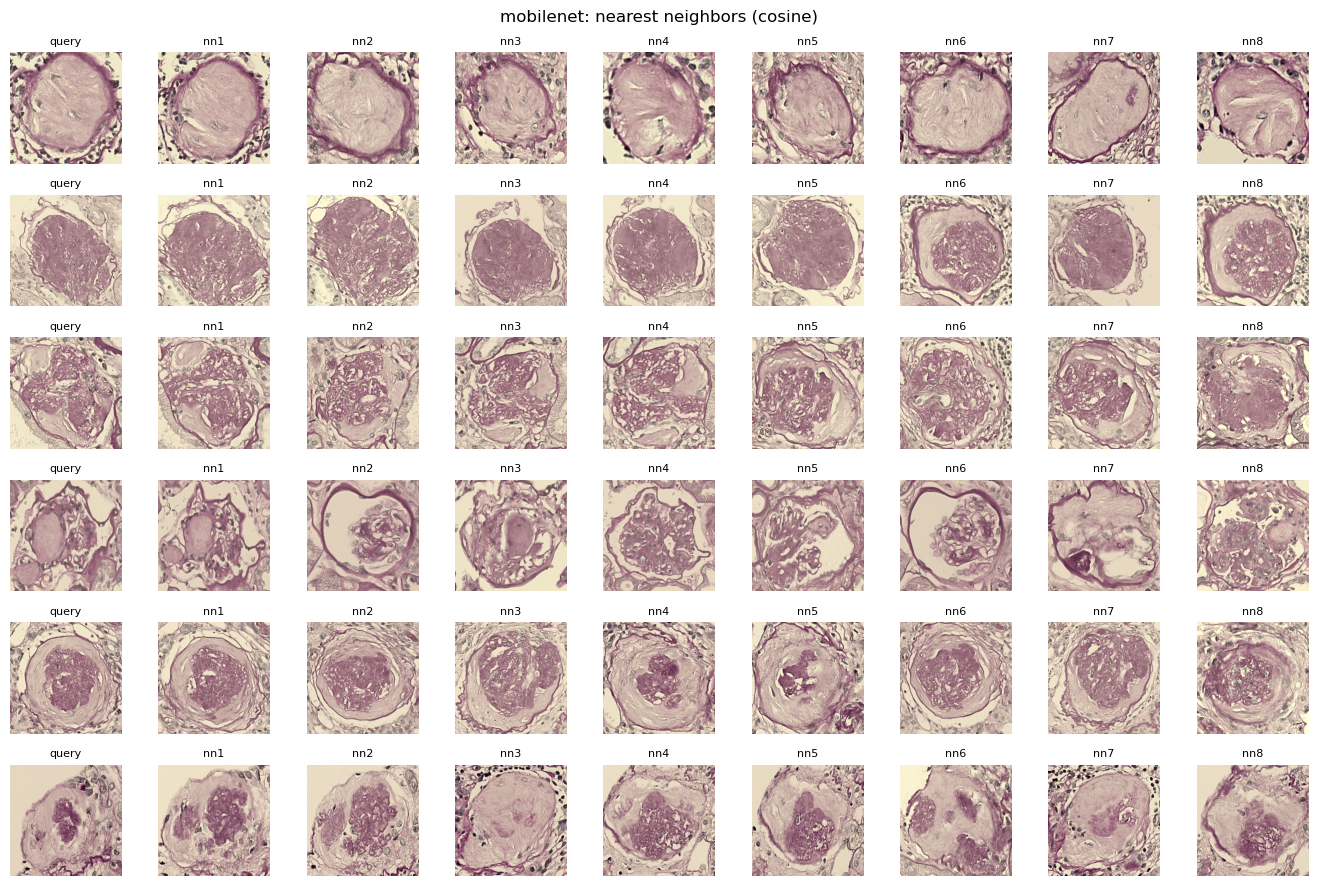

In [26]:
RUN_NN_GRIDS     = True
NN_GRID_BACKBONE = "mobilenet"
NN_GRID_QUERIES  = 6
NN_GRID_K        = 8

if RUN_NN_GRIDS and CROPS_DIR.is_dir() and NN_GRID_BACKBONE in embeddings:
    from PIL import Image
    crop_paths = sorted(p for p in CROPS_DIR.iterdir() if p.suffix.lower() == ".png")
    X = embeddings[NN_GRID_BACKBONE]
    if len(crop_paths) == X.shape[0]:
        Xp = normalize(X, norm="l2", axis=1)
        nn = NearestNeighbors(n_neighbors=NN_GRID_K + 1, metric="cosine").fit(Xp)
        rng = np.random.default_rng(RANDOM_STATE)
        queries = rng.choice(len(crop_paths), size=NN_GRID_QUERIES, replace=False)
        idx = nn.kneighbors(Xp[queries], return_distance=False)
        fig, axes = plt.subplots(NN_GRID_QUERIES, NN_GRID_K + 1,
                                 figsize=(1.5 * (NN_GRID_K + 1), 1.5 * NN_GRID_QUERIES))
        axes = np.atleast_2d(axes)
        for r, q in enumerate(queries):
            for c, gi in enumerate(idx[r]):
                ax = axes[r, c]
                ax.imshow(Image.open(crop_paths[gi]).convert("RGB"))
                ax.axis("off")
                ax.set_title("query" if c == 0 else f"nn{c}", fontsize=8)
        fig.suptitle(f"{NN_GRID_BACKBONE}: nearest neighbors (cosine)", fontsize=12)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"nn_grids_{NN_GRID_BACKBONE}.png", dpi=130, bbox_inches="tight")
        plt.show()
    else:
        print("crop count != embeddings; cannot build grids.")
else:
    print("NN grids skipped.")

### 9.7 Batch-controlled gradation (does the morphology signal survive removing same-slide neighbors?)

Section 9.2 showed all backbones have ~2–2.6× same-slide enrichment among neighbors, MobileNet
the highest. So its neighborhood advantage **could** be stain/slide rather than morphology. Here
we recompute the local gradation metrics using **only cross-slide neighbors** (and cross-slide
pairs for the distance correlation). If MobileNet stays high after removing same-slide neighbors,
the signal is morphological; if it collapses, it was batch.

In [27]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

RUN_BATCH_CONTROL = True

if "slide_id_from_filename" not in globals():
    def slide_id_from_filename(fname):
        stem = Path(fname).stem
        return stem.rsplit("_", 1)[0] if "_" in stem else stem


def _neigh_consistency(morph, neigh_lists):
    global_mad = float(np.mean(np.abs(morph - np.mean(morph))))
    if global_mad == 0:
        return np.nan
    locs = [np.mean(np.abs(morph[nb] - morph[i])) for i, nb in enumerate(neigh_lists) if len(nb) > 0]
    return float(1.0 - np.mean(locs) / global_mad) if locs else np.nan


def _morans_i(morph, neigh_lists):
    z = morph - np.mean(morph)
    denom = float(np.sum(z * z))
    if denom == 0:
        return np.nan
    num = 0.0
    w = 0.0
    for i, nb in enumerate(neigh_lists):
        for j in nb:
            num += z[i] * z[j]
            w += 1.0
    return float((len(morph) / w) * (num / denom)) if w > 0 else np.nan


if RUN_BATCH_CONTROL and ("morphology_score" in globals()) and CROPS_DIR.is_dir():
    morph = np.asarray(morphology_score, dtype=float)
    crop_names = sorted(p.name for p in CROPS_DIR.iterdir() if p.suffix.lower() == ".png")
    slide_ids = np.array([slide_id_from_filename(c) for c in crop_names])
    n = len(slide_ids)
    k = K_NEIGHBORS
    WINDOW = min(n - 1, 200)   # search window to find k cross-slide neighbors

    # shared pair sample for the distance-correlation (all vs cross-slide)
    rng = np.random.default_rng(RANDOM_STATE)
    pa = rng.integers(0, n, size=200000)
    pb = rng.integers(0, n, size=200000)
    ok = pa != pb
    pa, pb = pa[ok], pb[ok]
    cross_pair = slide_ids[pa] != slide_ids[pb]

    rows = []
    for name, X in embeddings.items():
        if X.shape[0] != n:
            print(f"  [SKIP] {name}: {X.shape[0]} emb != {n} crops")
            continue
        Xp = preprocess(X)
        nn = NearestNeighbors(n_neighbors=WINDOW + 1).fit(Xp)
        idx = nn.kneighbors(Xp, return_distance=False)[:, 1:]

        all_lists = [row[:k] for row in idx]
        cross_lists = []
        short = 0
        for i, row in enumerate(idx):
            keep = row[slide_ids[row] != slide_ids[i]][:k]
            if len(keep) < k:
                short += 1
            cross_lists.append(keep)

        d = np.linalg.norm(Xp[pa] - Xp[pb], axis=1)
        md = np.abs(morph[pa] - morph[pb])
        rows.append({
            "backbone": name,
            "neigh_all": _neigh_consistency(morph, all_lists),
            "neigh_crossslide": _neigh_consistency(morph, cross_lists),
            "moran_all": _morans_i(morph, all_lists),
            "moran_crossslide": _morans_i(morph, cross_lists),
            "distcorr_all": float(spearmanr(d, md).correlation),
            "distcorr_crossslide": float(spearmanr(d[cross_pair], md[cross_pair]).correlation),
            "pts_short_of_k_crossslide": short,
        })
        print(f"  batch-control done {name}")

    batch_df = pd.DataFrame(rows)
    for a, b, tag in [("neigh_all", "neigh_crossslide", "neigh"),
                      ("moran_all", "moran_crossslide", "moran"),
                      ("distcorr_all", "distcorr_crossslide", "distcorr")]:
        batch_df[f"{tag}_drop"] = batch_df[a] - batch_df[b]
    batch_df = batch_df.sort_values("neigh_crossslide", ascending=False).reset_index(drop=True)
    batch_df.to_csv(RESULTS_DIR / "batch_controlled_gradation.csv", index=False)
    print("\nCompare *_all vs *_crossslide. If MobileNet stays on top of neigh_crossslide,")
    print("its neighborhood advantage is morphological, not a slide/stain artefact.")
    display(batch_df[["backbone", "neigh_all", "neigh_crossslide", "neigh_drop",
                      "moran_all", "moran_crossslide", "distcorr_all", "distcorr_crossslide"]])
else:
    batch_df = None
    print("Batch control skipped (needs Section 5 + crops + a working slide_id_from_filename).")

  batch-control done densenet201
  batch-control done densenet
  batch-control done dinov2_base_cls
  batch-control done dinov2_base_patch
  batch-control done dinov3_base_cls
  batch-control done dinov3_base_patch
  batch-control done kimianet_1000
  batch-control done kimianet_224
  batch-control done mobilenet
  batch-control done nasnet
  batch-control done xception

Compare *_all vs *_crossslide. If MobileNet stays on top of neigh_crossslide,
its neighborhood advantage is morphological, not a slide/stain artefact.


,backbone,neigh_all,neigh_crossslide,neigh_drop,moran_all,moran_crossslide,distcorr_all,distcorr_crossslide
0,mobilenet,0.142981,0.054917,0.088063,0.405850,0.356677,0.275198,0.262884
1,densenet201,0.104696,0.030152,0.074545,0.405894,0.327976,0.268902,0.256122
2,dinov3_base_patch,0.113852,0.025616,0.088235,0.375567,0.318561,0.272182,0.261223
3,kimianet_1000,0.087892,0.016209,0.071684,0.340050,0.278391,0.125780,0.114429
4,densenet,0.069346,0.001452,0.067894,0.394330,0.345404,0.309387,0.301433
5,dinov3_base_cls,0.076270,-0.011777,0.088047,0.360311,0.300217,0.214956,0.202984
6,dinov2_base_patch,0.038759,-0.065755,0.104514,0.333324,0.243440,0.295214,0.285372
7,xception,-0.015098,-0.106567,0.091469,0.314983,0.259460,0.197183,0.185217
8,dinov2_base_cls,-0.033623,-0.132675,0.099052,0.277432,0.213418,0.192637,0.179036
9,kimianet_224,-0.083986,-0.149909,0.065923,0.255445,0.212211,0.176166,0.168253


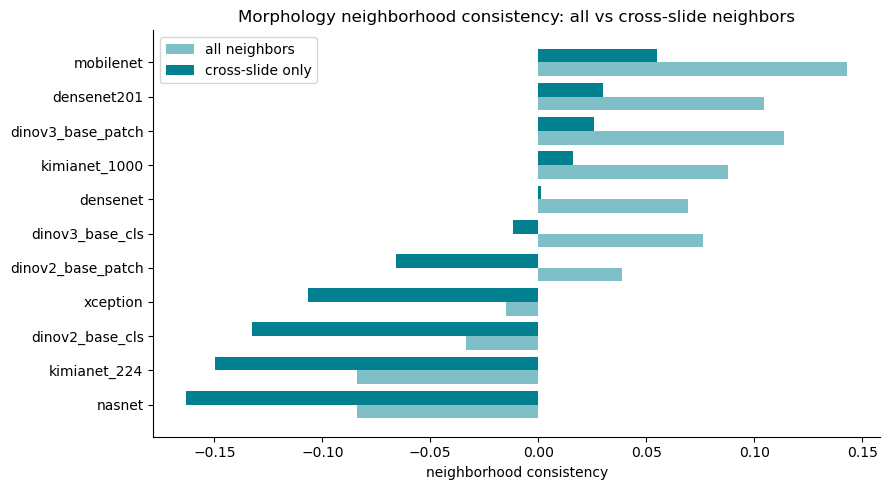

In [28]:
if batch_df is not None:
    d = batch_df.sort_values("neigh_crossslide")
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(y - 0.2, d["neigh_all"], height=0.4, label="all neighbors", color="#7fbfc7")
    ax.barh(y + 0.2, d["neigh_crossslide"], height=0.4, label="cross-slide only", color="#028090")
    ax.set_yticks(y); ax.set_yticklabels(d["backbone"])
    ax.set_xlabel("neighborhood consistency")
    ax.set_title("Morphology neighborhood consistency: all vs cross-slide neighbors")
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "batch_controlled_neigh_consistency.png", dpi=150, bbox_inches="tight")
    plt.show()

---
### Output files (`results/evaluation_notebook/`)

Core: `sanity_checks.csv`, `nearest_neighbor_metrics.csv`, `hopkins.csv`,
`separability_sweep_9configs.csv`, `separability_ranking_meanOf9.csv`,
`separability_noPCA_control.csv`, `gradation.csv`, `morphology_scores.csv`,
`augmentation_invariance.csv`, `SUMMARY.csv`.

Additional (Section 9): `gradation_bootstrap_ci.csv`, `slide_confound_embeddings.csv`,
`morphology_pc1_loadings.csv`, `morphology_axis_LOO_robustness.csv`,
`cross_backbone_distance_agreement.csv`, `cross_backbone_agreement_ranking.csv`,
`effective_dimensionality.csv`, plus all PNGs in `figures/`.